In [4]:
import pandas as pd
data = pd.read_excel("ENB2012_data.xlsx")
data.columns = [
    "Relative_Compactness",
    "Surface_Area",
    "Wall_Area",
    "Roof_Area",
    "Overall_Height",
    "Orientation",
    "Glazing_Area",
    "Glazing_Distribution",
    "Heating_Load",
    "Cooling_Load"
]

print("Columns renamed successfully!")
print(data.head())

Columns renamed successfully!
   Relative_Compactness  Surface_Area  Wall_Area  Roof_Area  Overall_Height  \
0                  0.98         514.5      294.0     110.25             7.0   
1                  0.98         514.5      294.0     110.25             7.0   
2                  0.98         514.5      294.0     110.25             7.0   
3                  0.98         514.5      294.0     110.25             7.0   
4                  0.90         563.5      318.5     122.50             7.0   

   Orientation  Glazing_Area  Glazing_Distribution  Heating_Load  Cooling_Load  
0            2           0.0                     0         15.55         21.33  
1            3           0.0                     0         15.55         21.33  
2            4           0.0                     0         15.55         21.33  
3            5           0.0                     0         15.55         21.33  
4            2           0.0                     0         20.84         28.28  


In [5]:
print(data.isnull().sum())
print(data.describe())

Relative_Compactness    0
Surface_Area            0
Wall_Area               0
Roof_Area               0
Overall_Height          0
Orientation             0
Glazing_Area            0
Glazing_Distribution    0
Heating_Load            0
Cooling_Load            0
dtype: int64
       Relative_Compactness  Surface_Area   Wall_Area   Roof_Area  \
count            768.000000    768.000000  768.000000  768.000000   
mean               0.764167    671.708333  318.500000  176.604167   
std                0.105777     88.086116   43.626481   45.165950   
min                0.620000    514.500000  245.000000  110.250000   
25%                0.682500    606.375000  294.000000  140.875000   
50%                0.750000    673.750000  318.500000  183.750000   
75%                0.830000    741.125000  343.000000  220.500000   
max                0.980000    808.500000  416.500000  220.500000   

       Overall_Height  Orientation  Glazing_Area  Glazing_Distribution  \
count       768.00000   768.000

In [9]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score

X = data.drop(columns = ["Heating_Load","Cooling_Load" ])
y = data["Cooling_Load"]

X_train, X_test, y_train, y_test = train_test_split(X,y, test_size = 0.2, random_state = 42)

model = RandomForestRegressor(n_estimators = 200 ,random_state = 42)
model.fit(X_train, y_train)

pred = model.predict(X_test)

print("MAE : ", mean_absolute_error(y_test,pred))
print("R2:",r2_score(y_test,pred))

MAE :  1.0743259740259705
R2: 0.9673361040840911


injecting controll anomalies

In [11]:
import numpy as np

y_test_modified = y_test.copy()

np.random.seed(42)

anomaly_indices = np.random.choice(y_test.index, size = int(0.1*len(y_test)), replace = False)

y_test_modified.loc[anomaly_indices] += np.random.uniform(5,15, size = len(anomaly_indices))

print("Injected anomalies : ", len(anomaly_indices))

Injected anomalies :  15


residual based detection

In [17]:
residuals = y_test - pred
threshold = residuals.mean() + 1.5 * residuals.std()

anomalies_detected = residuals > threshold

print("Detected anomalies : ", anomalies_detected.sum())

Detected anomalies :  14


In [18]:
true_anomalies = y_test.index.isin(anomaly_indices)
true_anomalies = pd.Series(true_anomalies, index = y_test.index)

tp = ((anomalies_detected == True) & (true_anomalies == True)).sum()
fp = ((anomalies_detected == True) & (true_anomalies == False)).sum()
fn = ((anomalies_detected ==False)& (true_anomalies == True)).sum()

print("true positives : ",tp)
print("false positives : ", fp)
print("fasle negatives :",fn)

recall = tp / (tp + fn)

precision = tp/(tp + fp) if (tp + fp) > 0 else 0

print("recall :" ,recall)
print("precision : ",precision)

true positives :  1
false positives :  13
fasle negatives : 14
recall : 0.06666666666666667
precision :  0.07142857142857142


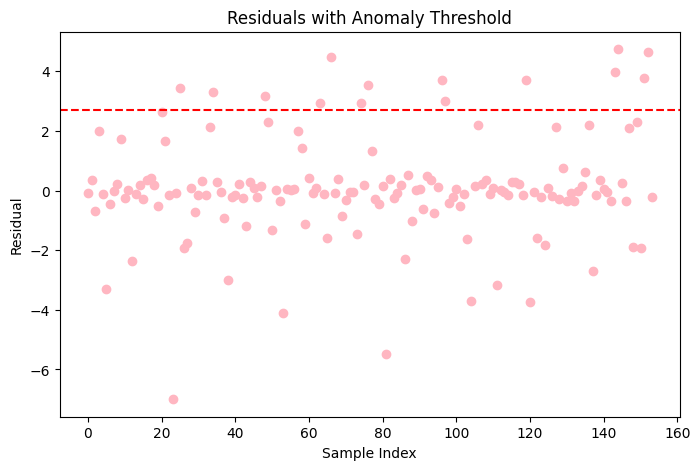

In [33]:

import matplotlib.pyplot as plt

plt.figure(figsize =(8,5))

plt.scatter(range(len(residuals)), residuals, color = "lightpink")
plt.axhline(threshold,color = 'red', linestyle ="--")
plt.title("Residuals with Anomaly Threshold")
plt.xlabel("Sample Index")
plt.ylabel("Residual")
plt.show()

feature importance

In [34]:
importances = model.feature_importances_

for feature, importance in zip(X.columns, importances):
    print(feature, ":", round(importance, 3))

Relative_Compactness : 0.365
Surface_Area : 0.118
Wall_Area : 0.041
Roof_Area : 0.087
Overall_Height : 0.313
Orientation : 0.012
Glazing_Area : 0.049
Glazing_Distribution : 0.016
